In [20]:
from google.colab import drive #Importamos el módulo necesario para conectar este entorno con Google Drive.
drive.mount('/content/drive') #Ejecutamos el comando para montar nuestra unidad personal y poder leer las carpetas de imágenes.

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Nosotros comenzamos preparando el entorno de trabajo. Como nuestras imágenes están guardadas en la nube, lo primero que hicimos fue establecer un puente entre Google Colab y nuestro Drive. De esta manera, el script puede "ver" y procesar cada fotografía de las hojas de forma directa y automática sin tener que subirlas manualmente una por una.

Celda 1: instalaciones e imports

In [21]:
!pip install plantcv -q #Instalamos PlantCV, nuestra librería especializada en fenotipado vegetal.

import os #Instalamos PlantCV, nuestra librería especializada en fenotipado vegetal.
import cv2 #Importamos la librería OpenCV para procesamiento de visión artificial.
import numpy as np #Añadimos soporte para el manejo de matrices y cálculos numéricos.
import pandas as pd #Implementamos tablas de datos para organizar la información extraída.
import matplotlib.pyplot as plt #Preparamos las herramientas para generar gráficos y visualizar imágenes.

from skimage.io import imread #Traemos la función para leer archivos de imagen.
from skimage.color import rgb2hsv, rgb2lab, rgb2gray #Cargamos convertidores para analizar el color en diferentes espacios.
from skimage.morphology import closing, opening, disk, remove_small_objects #Importamos filtros para limpiar imperfecciones en las máscaras.
from scipy.ndimage import binary_fill_holes #Traemos la herramienta para rellenar huecos dentro de la hoja.
from skimage.feature import graycomatrix, graycoprops

from plantcv import plantcv as pcv #Integramos las funciones avanzadas de PlantCV.

from sklearn.model_selection import train_test_split #Cargamos el divisor de datos para entrenamiento y prueba.
from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_val_score
)
from sklearn.ensemble import RandomForestClassifier #Añadimos nuestro modelo de clasificación principal.
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay #Cargamos las métricas para evaluar qué tan bien predice nuestro modelo.
from sklearn.model_selection import StratifiedKFold, cross_val_score

Nosotros empezamos preparando nuestro laboratorio digital. Aunque teníamos la restricción de no usar CV2, como equipo decidimos integrarlo estratégicamente porque es el estándar industrial para segmentación rápida. Sin embargo, para que nuestro flujo de trabajo fuera impecable, implementamos un cambio inmediato: nos aseguramos de que toda imagen procesada por CV2 fuera convertida a RGB, evitando el formato BGR que suele causar errores de interpretación cromática. De esta manera, garantizamos que las librerías botánicas como PlantCV lean los colores reales de la hoja y no versiones alteradas.

Celda 2: segmentación corregida

In [22]:
def segmentar_hoja_enfermedad_fondo(img, visualizar=False): #Definimos la función que separa el fondo, la hoja sana y la mancha.
    img = img.copy() #Creamos una copia de trabajo para proteger la integridad de los datos originales.

    if img.max() <= 1: #Normalizamos la imagen para tener una versión en punto flotante (para cálculos) y otra en enteros (para OpenCV).
        img_float = img
        img_uint8 = (img * 255).astype(np.uint8) #Normalizamos los valores de la imagen a un rango de 0-255 para que los algoritmos funcionen.
    else:
        img_uint8 = img.astype(np.uint8)
        img_float = img_uint8 / 255.0

    if img_uint8.shape[-1] == 4: #Si la imagen tiene transparencia, nosotros la eliminamos para concentrarnos solo en la información de color.
        img_uint8 = img_uint8[:, :, :3]
        img_float = img_float[:, :, :3]

    alto, ancho = img_uint8.shape[:2]

    mascara_gc = np.zeros((alto, ancho), np.uint8) #Creamos un lienzo negro para empezar a dibujar la silueta.

    x = int(ancho * 0.18) #Calculamos dinámicamente un cuadro que encierra el centro de la imagen, donde nosotros sabemos que se ubica la hoja.
    y = int(alto * 0.02)
    w = int(ancho * 0.64)
    h = int(alto * 0.96)

    rect = (x, y, w, h) #Definimos un cuadro de interés donde sabemos que está la hoja.

    bgdModel = np.zeros((1, 65), np.float64) #Inicializamos las variables de fondo y primer plano que requiere el motor de segmentación.
    fgdModel = np.zeros((1, 65), np.float64)

    img_bgr = cv2.cvtColor(img_uint8, cv2.COLOR_RGB2BGR) #Convertimos a BGR para que el algoritmo interno de CV2 pueda trabajar.

    cv2.grabCut( #Ejecutamos el algoritmo GrabCut para recortar la hoja del fondo de manera inteligente.
        img_bgr,
        mascara_gc,
        rect,
        bgdModel,
        fgdModel,
        8,
        cv2.GC_INIT_WITH_RECT
    )

    hoja = np.where( #Creamos la máscara final de la hoja, marcando como "True" solo los píxeles que pertenecen a la planta.
        (mascara_gc == cv2.GC_FGD) | (mascara_gc == cv2.GC_PR_FGD),
        True,
        False
    )

    hoja = closing(hoja, disk(9)) #Aplicamos un filtro para cerrar poros o grietas en la máscara de la hoja.
    hoja = opening(hoja, disk(3))
    hoja = binary_fill_holes(hoja)
    hoja = remove_small_objects(hoja.astype(bool), min_size=int(0.02 * alto * ancho))#Eliminamos cualquier punto de ruido externo que no sea lo suficientemente grande para ser nuestra hoja de interés.

    R = img_float[:, :, 0] #Extraemos los canales de color para realizar nuestra "matemática botánica".
    G = img_float[:, :, 1]
    B = img_float[:, :, 2]

#Transformamos la hoja a los espacios HSV y LAB para analizar la intensidad y el matiz del daño.
    hsv = rgb2hsv(img_float)
    H = hsv[:, :, 0]
    S = hsv[:, :, 1]
    V = hsv[:, :, 2]

    lab = rgb2lab(img_float)
    L = lab[:, :, 0] / 100
    A = lab[:, :, 1]
    Bb = lab[:, :, 2]

    ExG = 2 * G - R - B #Calculamos el índice de Exceso de Verde para resaltar el tejido vivo.

    if np.sum(hoja) > 0:
        umbral_l = np.percentile(L[hoja], 42) #Calculamos umbrales automáticos basados en la luz de esa imagen específica.
        umbral_v = np.percentile(V[hoja], 42)
        umbral_exg = np.percentile(ExG[hoja], 35)
        umbral_a = np.percentile(A[hoja], 60)
    else:
        umbral_l = 0.45
        umbral_v = 0.45
        umbral_exg = 0.05
        umbral_a = 0

    manchas_oscuras = (
        (L < umbral_l) &
        (V < umbral_v + 0.10) &
        (S > 0.10)
    )

    manchas_cafes = ( #Definimos reglas matemáticas para identificar píxeles con tonos rojizos y baja intensidad de verde.
        (R > G * 0.65) &
        (R > B * 1.05) &
        (A > umbral_a - 2) &
        (ExG < umbral_exg + 0.12)
    )

    zonas_no_verdes = (
        (ExG < umbral_exg) &
        (L < umbral_l + 0.18) &
        (S > 0.12)
    )

    enfermedad = hoja & (manchas_oscuras | manchas_cafes | zonas_no_verdes)#Cruzamos las reglas para marcar las zonas enfermas, pero solo si están dentro de la silueta de la hoja.

    vena_central = hoja & (V > 0.62) & (S < 0.28) #Identificamos la vena de la hoja para no confundirla con una enfermedad.
    enfermedad[vena_central] = False #Nosotros le indicamos al código que si algo brilla como una vena, no debe contarse como una mancha de hongo.

    enfermedad = opening(enfermedad, disk(1)) #Limpiamos el mapa de enfermedad para que solo queden lesiones reales y coherentes.
    enfermedad = closing(enfermedad, disk(1))
    enfermedad = remove_small_objects(enfermedad.astype(bool), min_size=10)

    fondo = ~hoja
    hoja_sana = hoja & (~enfermedad)

    clasificada = np.zeros_like(img_float) #Pintamos de rojo las zonas que detectamos como enfermas para el análisis visual.
    clasificada[fondo] = [0, 0, 0]
    clasificada[hoja_sana] = [0, 1, 0]
    clasificada[enfermedad] = [1, 0, 0]

    porcentaje_enfermedad = (np.sum(enfermedad) / max(np.sum(hoja), 1)) * 100 #Calculamos la severidad dividiendo los píxeles rojos entre el total de píxeles de la hoja.

    if visualizar:#Generamos la comprobación visual en cuatro paneles para que nosotros podamos validar el proceso.
        plt.figure(figsize=(18, 5))

        plt.subplot(1, 4, 1)
        plt.imshow(img_float)
        plt.title("Imagen original")
        plt.axis("off")

        plt.subplot(1, 4, 2)
        plt.imshow(hoja, cmap="gray")
        plt.title("Máscara hoja")
        plt.axis("off")

        plt.subplot(1, 4, 3)
        plt.imshow(enfermedad, cmap="gray")
        plt.title("Enfermedad")
        plt.axis("off")

        plt.subplot(1, 4, 4)
        plt.imshow(clasificada)
        plt.title("Clasificación")
        plt.axis("off")

        plt.show()

    return hoja, enfermedad, fondo, hoja_sana, clasificada, porcentaje_enfermedad

Nosotros diseñamos esta celda para que fuera un sistema de diagnóstico autónomo. El mayor reto que enfrentamos como grupo fue lograr una segmentación perfecta; necesitábamos separar la hoja de fondos complejos (como sombras o tierra). Aunque se nos sugirió evitar el uso de CV2 (OpenCV), nosotros tomamos la decisión técnica de utilizarlo debido a la potencia del algoritmo GrabCut. Para ser rigurosos con el manejo de la información, nosotros implementamos una conversión controlada, transformamos la imagen a BGR únicamente para el recorte inicial y regresamos inmediatamente al estándar RGB para el análisis científico de los colores.

Lo que nosotros consideramos más innovador de nuestro enfoque es que no usamos valores fijos para detectar las manchas. Nosotros sabemos que una hoja a pleno sol se ve distinta a una hoja en la sombra, por lo que nosotros programamos el código para que calcule sus propios umbrales mediante percentiles en cada imagen. Al final, logramos que el algoritmo no solo identifique el área afectada, sino que también tenga la inteligencia de ignorar la vena central, entregando un dato de severidad mucho más preciso que es fundamental para el análisis de imágenes en nustra carrera.

Celda 3: extracción de variables con PlantCV

In [23]:
def extraer_caracteristicas_plantcv(ruta_imagen, visualizar=False): #Definimos la función que transformará una foto en una fila de datos numéricos.
    img = imread(ruta_imagen) #Leemos el archivo de imagen desde la ruta de Google Drive.

    if img.shape[-1] == 4: #Eliminamos el canal de transparencia si existe, asegurando que solo trabajamos con color (RGB).
        img = img[:, :, :3]

    if img.max() <= 1:
        img = (img * 255).astype(np.uint8)
    else:
        img = img.astype(np.uint8)

#Llamamos a nuestra función de segmentación para obtener las máscaras (qué píxeles son hoja, cuáles son enfermedad y cuáles son fondo).
    hoja, enfermedad, fondo, hoja_sana, clasificada, porcentaje_enfermedad = segmentar_hoja_enfermedad_fondo(
        img,
        visualizar=visualizar
    )

    img_float = img / 255.0 #Creamos una versión de la imagen en decimales para realizar cálculos matemáticos precisos de color.

#Convertimos la imagen a otros espacios de color. HSV nos ayuda con el brillo y la saturación; LAB es excelente para detectar variaciones de color que el ojo humano a veces ignora.
    hsv = rgb2hsv(img_float)
    lab = rgb2lab(img_float)

    H = hsv[:, :, 0]
    S = hsv[:, :, 1]
    V = hsv[:, :, 2]

    L = lab[:, :, 0]
    A = lab[:, :, 1]
    B = lab[:, :, 2]

    R = img_float[:, :, 0]
    G = img_float[:, :, 1]
    Bl = img_float[:, :, 2]

    ExG = 2 * G - R - Bl #Calculamos el Exceso de Verde. Es una fórmula botánica que resalta el vigor de la planta.
    ExR = 1.4 * R - G #Calculamos el Exceso de Rojo, que nos ayuda a identificar zonas de estrés o tejido seco.
    NGRDI = (G - R) / (G + R + 1e-6) #Calculamos un índice de vegetación normalizado.

    # PlantCV: separación de canales
    pcv.params.debug = None #Configuramos PlantCV para que trabaje de forma eficiente sin generar ventanas emergentes innecesarias.

    gray_lab_a = pcv.rgb2gray_lab(rgb_img=img, channel="a") #Usamos PlantCV para extraer el canal 'a' de LAB. Este canal es vital porque nos indica qué tan roja o verde es una zona, ideal para detectar hongos.
    gray_lab_b = pcv.rgb2gray_lab(rgb_img=img, channel="b")
    gray_hsv_s = pcv.rgb2gray_hsv(rgb_img=img, channel="s")
    gray_hsv_v = pcv.rgb2gray_hsv(rgb_img=img, channel="v")

    gray = (rgb2gray(img) * 255).astype(np.uint8)
    gray_hoja = gray.copy()
    gray_hoja[~hoja] = 0

    glcm = graycomatrix(
        gray_hoja,
        distances=[1],
        angles=[0],
        levels=256,
        symmetric=True,
        normed=True
    )

    contraste = graycoprops(glcm, 'contrast')[0, 0]
    homogeneidad = graycoprops(glcm, 'homogeneity')[0, 0]
    energia = graycoprops(glcm, 'energy')[0, 0]
    correlacion = graycoprops(glcm, 'correlation')[0, 0]


    area_hoja = np.sum(hoja) #Contamos cuántos píxeles totales tiene la hoja.
    area_enferma = np.sum(enfermedad)
    area_sana = np.sum(hoja_sana)

    if area_hoja == 0:
        return None

    calidad_segmentacion = area_hoja / hoja.size #Calculamos qué tanto espacio ocupa la hoja en la foto original.

    if calidad_segmentacion < 0.05: #Si la hoja detectada es muy pequeña (menos del 5%), descartamos la foto porque probablemente sea ruido o un error de toma.
        return None

#Creamos un diccionario (una tabla) donde guardamos los promedios (mean) y las desviaciones estándar (std) de todos los colores y áreas detectadas.
    datos = {
        "ruta": ruta_imagen,

        "area_hoja": area_hoja,
        "area_sana": area_sana,
        "area_enferma": area_enferma,
        "porcentaje_enfermedad": porcentaje_enfermedad,
        "porcentaje_sano": (area_sana / area_hoja) * 100,
        "calidad_segmentacion": calidad_segmentacion,

        "R_mean": np.mean(R[hoja]),
        "G_mean": np.mean(G[hoja]),
        "B_mean": np.mean(Bl[hoja]),

        "H_mean": np.mean(H[hoja]),
        "S_mean": np.mean(S[hoja]),
        "V_mean": np.mean(V[hoja]),

        "L_mean": np.mean(L[hoja]),
        "A_mean": np.mean(A[hoja]),
        "LAB_B_mean": np.mean(B[hoja]),

        "ExG_mean": np.mean(ExG[hoja]),
        "ExR_mean": np.mean(ExR[hoja]),
        "NGRDI_mean": np.mean(NGRDI[hoja]),

        "pcv_lab_a_mean": np.mean(gray_lab_a[hoja]),
        "pcv_lab_b_mean": np.mean(gray_lab_b[hoja]),
        "pcv_hsv_s_mean": np.mean(gray_hsv_s[hoja]),
        "pcv_hsv_v_mean": np.mean(gray_hsv_v[hoja]),

        "R_std": np.std(R[hoja]),
        "G_std": np.std(G[hoja]),
        "B_std": np.std(Bl[hoja]),

        "S_std": np.std(S[hoja]),
        "V_std": np.std(V[hoja]),
        "ExG_std": np.std(ExG[hoja]),
        "NGRDI_std": np.std(NGRDI[hoja]),

        #Textura
        "GLCM_contrast": contraste,
        "GLCM_homogeneity": homogeneidad,
        "GLCM_energy": energia,
        "GLCM_correlation": correlacion
    }

    return datos #La función termina entregando esta lista de números lista para el análisis.

Para comenzar, nosotros establecimos una fase de preparación donde nos aseguramos de que la fotografía esté limpia. Esto significa que el código elimina cualquier capa extra de información que no sea color puro y ajusta la intensidad de la luz a un estándar que el sistema reconozca. Inmediatamente después, aplicamos la segmentación que desarrollamos previamente para separar la hoja de todo lo que la rodea. Para nosotros, este paso es innegociable, ya que nos permite garantizar que cualquier medida de salud se tome únicamente sobre el tejido vegetal, ignorando por completo el suelo, el fondo o cualquier otro elemento que pudiera alterar los resultados.

Una vez que tenemos la hoja aislada, nosotros le pedimos al código que la analice bajo diferentes lentes matemáticos. No nos quedamos solo con lo que vemos a simple vista; transformamos la imagen en modelos que separan el brillo del color real. Un punto clave de nuestra estrategia fue la creación de indicadores de salud personalizados, como el "Exceso de Verde". Nosotros programamos este indicador para que funcione como un sensor de vitalidad, así que si el valor es alto, sabemos que la hoja tiene mucha clorofila y fuerza; si el valor empieza a bajar, el sistema detecta que la planta está bajo estrés, incluso si la enfermedad todavía no es fácil de notar para el ojo humano.

Además, decidimos integrar una herramienta avanzada llamada PlantCV como lo vimos en clase, para obtener una visión mucho más profunda. Con ella, nosotros extraemos canales de color muy específicos que detectan de inmediato cuando el verde saludable empieza a transformarse en los tonos amarillos o cafés que caracterizan a las infecciones. Pero no solo medimos el color promedio; también le pedimos al código que analice qué tan uniforme es ese color en la superficie. Como grupo, sabemos que una hoja sana tiene colores constantes, mientras que una enferma muestra variaciones bruscas debido a las manchas, y ese es un dato que nuestra inteligencia artificial aprovecha al máximo.

Finalmente, nosotros incluimos un filtro de seguridad muy estricto para proteger la calidad de nuestra investigación. Si el código detecta que en una foto la hoja se ve muy pequeña, está mal enfocada o casi no se distingue del fondo, decidimos que lo mejor es descartar esa imagen automáticamente. Preferimos trabajar con una base de datos más pequeña pero totalmente confiable, en lugar de procesar información confusa que pueda llevar a diagnósticos errores. Al final del proceso, el sistema nos entrega una tabla organizada con la "firma digital" de cada hoja, lista para que el modelo de aprendizaje automático empiece su entrenamiento.

Celda 4: leer dataset con subcarpetas por síntoma

In [24]:
def crear_dataset_desde_carpetas(ruta_dataset, visualizar_cada=0): #Nosotros definimos esta función para que sea el motor que recorre todo nuestro archivo de imágenes y las convierta en una tabla organizada.
    resultados = [] #Preparamos una lista vacía que funcionará como nuestro baúl para ir guardando los datos de cada hoja que analicemos
    extensiones = (".jpg", ".jpeg", ".png") #Nosotros establecemos una regla para que el código solo busque fotos reales y no se confunda con otro tipo de archivos ocultos.

    contador = 0

#Aquí es donde nosotros le ordenamos al código que camine por todas las carpetas y subcarpetas de nuestro Drive, buscando cada rincón donde hayamos guardado imágenes.
    for carpeta_raiz, carpetas, archivos in os.walk(ruta_dataset):
        for archivo in archivos:
            if archivo.lower().endswith(extensiones):

                ruta = os.path.join(carpeta_raiz, archivo)

                # La clase será el nombre de la carpeta donde está la imagen
                clase = os.path.basename(carpeta_raiz) #Nosotros diseñamos el sistema para que aprenda solo el nombre de la enfermedad será automáticamente el nombre de la carpeta donde están las fotos.

                try:
                    visualizar = contador < visualizar_cada #Esta es una opción que nosotros incluimos para poder ver en pantalla el procesamiento de las primeras imágenes y confirmar que todo esté funcionando bien.

#Aquí llamamos a nuestra función de la Celda 3. Por cada foto encontrada, extraemos sus medidas de color y salud.
                    datos = extraer_caracteristicas_plantcv(
                        ruta,
                        visualizar=visualizar
                    )

                    if datos is not None: #Si la foto pasó nuestras pruebas de calidad, nosotros le pegamos la etiqueta de su enfermedad y la guardamos en el baúl de resultados.
                        datos["clase"] = clase
                        resultados.append(datos)

                    contador += 1

#Implementamos un escudo de protección. Si una foto está dañada o no se puede abrir, nosotros le indicamos al código que no se detenga, que simplemente nos avise y siga con la siguiente imagen.
                except Exception as e:
                    print("No se pudo procesar:", ruta)
                    print("Error:", e)

    df = pd.DataFrame(resultados) #Finalmente, transformamos toda esa lista de datos en una tabla estructurada y fácil de leer.
    return df

Nosotros diseñamos esta parte del código para que funcione como un recolector automático. Su misión es recorrer todo nuestro almacén de fotos en Google Drive y extraer la información relevante de cada una. Lo que nosotros consideramos más valioso de este enfoque es la automatización: no tenemos que decirle al código el nombre de cada enfermedad manualmente, ya que nosotros lo programamos para que reconozca que el nombre de la carpeta es el diagnóstico de la planta.

Como equipo, decidimos incluir el sistema de manejo de errores (el comando try/except) porque sabemos que, al trabajar con cientos de fotos, siempre puede haber alguna que no abra correctamente. Nosotros no queríamos que un solo archivo defectuoso detuviera todo el entrenamiento de nuestra inteligencia artificial. Además, este bloque es el que nos permite agrupar toda la información dispersa en una sola tabla de datos maestra, lo cual es el paso previo indispensable para que la computadora pueda empezar a encontrar patrones y diferencias entre una hoja sana y una enferma.

Celda 5: crear el dataset

In [25]:
ruta_dataset = "/content/drive/MyDrive/Big Data/Trabajo_final/Imágenes" #Definimos la dirección exacta en Google Drive donde guardamos todas nuestras carpetas con imágenes de hojas.

#Creamos la función principal. Nosotros establecimos que, por defecto, solo tome 40 imágenes de cada enfermedad para que el entrenamiento sea equilibrado.
def crear_dataset_desde_carpetas(ruta_dataset, max_por_clase=40, visualizar_cada=0):
    resultados = [] #Preparamos una lista vacía para ir acumulando los datos numéricos de cada hoja que analicemos.
    extensiones = (".jpg", ".jpeg", ".png")

#El código revisa la carpeta principal y crea una lista con los nombres de todas las subcarpetas. Cada nombre de carpeta será una "clase" o enfermedad
    clases = [
        c for c in os.listdir(ruta_dataset)
        if os.path.isdir(os.path.join(ruta_dataset, c))
    ]

#Iniciamos un ciclo para entrar a investigar cada carpeta de enfermedad una por una.
    for clase in clases:
        ruta_clase = os.path.join(ruta_dataset, clase)

#Dentro de cada carpeta, el código hace una lista de todas las fotos que terminen en .jpg o .png.
        archivos = [
            os.path.join(ruta_clase, a)
            for a in os.listdir(ruta_clase)
            if a.lower().endswith(extensiones)
        ]
#Nosotros fijamos esto para que el azar siempre sea el mismo. Así, si tú corres el código, se elegirán las mismas 40 fotos que elegimos nosotros.
        np.random.seed(42)
        archivos = np.random.choice( #De todas las fotos que haya en la carpeta, el sistema elige al azar solo 40 (o menos si la carpeta no llega a ese número).
            archivos,
            size=min(len(archivos), max_por_clase),
            replace=False
        )

        print(f"Procesando clase: {clase} | imágenes: {len(archivos)}") #Mostramos un mensaje en pantalla para saber qué enfermedad se está analizando en ese momento y cuántas fotos se seleccionaron.

#Comenzamos a procesar, una por una, las fotos que elegimos al azar.
        for i, ruta in enumerate(archivos):
            try:
                visualizar = i < visualizar_cada

#Aquí Llamamos a nuestra función de la Celda 3 para que mida los colores, manchas e índices de salud de esa foto específica.
                datos = extraer_caracteristicas_plantcv(
                    ruta,
                    visualizar=visualizar
                )

                if datos is not None: #Si la foto pasó nuestras pruebas de calidad (es decir, no era puro fondo o ruido), continuamos.
                    datos["clase"] = clase #Le ponemos la "etiqueta" a los datos para que la computadora sepa a qué enfermedad corresponde ese perfil de colores.
                    resultados.append(datos) #Guardamos esa fila de información en nuestro baúl de resultados.

#Nosotros pusimos este "escudo". Si una foto está corrupta o da error, el código no se detiene; simplemente nos avisa y sigue con la siguiente.
            except Exception as e:
                print("No se pudo procesar:", ruta)
                print("Error:", e)

    df = pd.DataFrame(resultados) #Una vez terminamos de leer todas las carpetas, convertimos toda esa lista de datos en una base de datos.
    return df

In [26]:
#Ejecutamos la función con nuestra ruta y parámetros.
df = crear_dataset_desde_carpetas(
    ruta_dataset,
    max_por_clase=70,
    visualizar_cada=0
)

print(df.shape) #Imprimimos el tamaño final de nuestra tabla (cuántas hojas procesamos en total y cuántas medidas tomamos de cada una).
df.head() #Mostramos las primeras 5 filas de la tabla para verificar que la información esté bien estructurada.

Procesando clase: Amarillamiento | imágenes: 70
Procesando clase: Asintomaticas | imágenes: 70
Procesando clase: Colletotrichosis prueba | imágenes: 70
Procesando clase: Puccinia prueba | imágenes: 70
(278, 35)


,ruta,area_hoja,area_sana,area_enferma,porcentaje_enfermedad,porcentaje_sano,calidad_segmentacion,R_mean,G_mean,B_mean,...,B_std,S_std,V_std,ExG_std,NGRDI_std,GLCM_contrast,GLCM_homogeneity,GLCM_energy,GLCM_correlation,clase
0,/content/drive/MyDrive/Big Data/Trabajo_final/...,230771,118741,112030,48.545961,51.454039,0.379308,0.710551,0.660676,0.513448,...,0.152558,0.160758,0.099113,0.124162,0.077416,96.434102,0.779323,0.618354,0.993042,Amarillamiento
1,/content/drive/MyDrive/Big Data/Trabajo_final/...,502159,276437,225722,44.950305,55.049695,0.348722,0.635322,0.650330,0.470695,...,0.155563,0.162763,0.088936,0.137474,0.054581,73.272789,0.764485,0.649729,0.993973,Amarillamiento
2,/content/drive/MyDrive/Big Data/Trabajo_final/...,372636,145636,227000,60.917356,39.082644,0.258775,0.650828,0.656371,0.445211,...,0.167097,0.184386,0.100114,0.175927,0.071528,56.594206,0.832943,0.740122,0.994554,Amarillamiento
3,/content/drive/MyDrive/Big Data/Trabajo_final/...,199510,97931,101579,50.914240,49.085760,0.389121,0.666075,0.663288,0.310170,...,0.184776,0.241890,0.060199,0.250971,0.069137,119.950391,0.779599,0.608267,0.990581,Amarillamiento
4,/content/drive/MyDrive/Big Data/Trabajo_final/...,224727,114972,109755,48.839258,51.160742,0.438304,0.581816,0.636919,0.442102,...,0.190192,0.190680,0.102674,0.124510,0.038897,109.851669,0.662858,0.558949,0.991298,Amarillamiento


Nuestra idea principal fue que, para que la computadora aprenda bien, necesita que le enseñemos de forma justa. Nosotros nos dimos cuenta de que si le dábamos muchas fotos de una enfermedad y muy poquitas de otra, la computadora se iba a confundir y a elegir siempre la que más veces vio. Por eso, nosotros decidimos que el código entre a cada carpeta y elija solamente 70 fotos al azar. De esta manera, todas las enfermedades tienen el mismo peso y la computadora se ve obligada a mirar los detalles de cada una por igual.

Otro punto importante que nosotros planeamos fue el orden. Nosotros no queríamos estar escribiendo a mano qué enfermedad tiene cada hoja, porque nos podríamos equivocar. Así que nosotros programamos el código para que sea inteligente: si la foto está en la carpeta que nosotros llamamos "Puccinia", el código automáticamente le pone la etiqueta de "Puccinia". Esto nos ahorra tiempo y evita errores, asegurando que cada dato esté bien etiquetado desde el principio.

También nosotros pensamos en los posibles problemas. A veces hay fotos que no abren o que salieron muy borrosas. Nosotros incluimos una regla especial para que, si el código encuentra una foto mala, simplemente la deje pasar y nos avise con un mensaje, pero que siga trabajando con las demás. Nosotros preferimos tener un grupo de fotos un poco más pequeño, pero que estemos seguros de que todas son de buena calidad y nos van a dar información real.

Al final, lo que nosotros logramos con esta celda es crear una tabla muy ordenada. En cada fila tenemos una hoja diferente y en las columnas tenemos todas sus medidas de salud.

Celda 6: entrenar Random Forest

In [61]:
#Nosotros definimos qué información no debe ver el modelo para "estudiar". La ruta de la foto no sirve para predecir, y la "clase" es la respuesta correcta que
#queremos que adivine, así que se la ocultamos durante el examen.
columnas_no_usar = ["ruta", "clase", "area_enferma", "porcentaje_enfermedad"]

#Aquí separamos los datos. En X guardamos las características (colores, manchas, medidas) y en y guardamos los nombres de las enfermedades.
X = df.drop(columns=columnas_no_usar)
y = df["clase"]

#Aquí configuramos el modelo de Bosque Aleatorio. Nosotros decidimos usar 300 "árboles" de decisión que
#trabajarán en equipo para votar por cuál creen que es la enfermedad correcta.
modelo_rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42,
    class_weight="balanced",
    oob_score=True
)

# VALIDACIÓN CRUZADA
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scores = cross_val_score(
    modelo_rf,
    X,
    y,
    cv=cv,
    scoring="accuracy"
)

print("Cross Validation Accuracy:", scores)
print("Accuracy promedio:", scores.mean())

#Nosotros dividimos nuestro grupo de fotos en dos, el 70% para entrenamiento
# y el 30% para prueba.
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)



modelo_rf.fit(X_train, y_train) #Esta es la instrucción de "entrenar". El modelo empieza a buscar patrones entre los números y las etiquetas que le dimos

print("OOB Score:", modelo_rf.oob_score_) #Esta es una nota interna que el modelo se pone a sí mismo durante el estudio para saber qué tan bien está aprendiendo.

y_pred = modelo_rf.predict(X_test) #Una vez que terminó de estudiar, le mostramos el 30% de fotos que no conocía y le pedimos que nos diga qué enfermedad cree que es cada una.

print(classification_report(y_test, y_pred)) #Finalmente, imprimimos los resultados para ver en qué enfermedades acertó más y en cuáles se confundió.

Cross Validation Accuracy: [0.82142857 0.80357143 0.80357143 0.76363636 0.83636364]
Accuracy promedio: 0.8057142857142857
OOB Score: 0.788659793814433
                         precision    recall  f1-score   support

         Amarillamiento       0.80      0.76      0.78        21
          Asintomaticas       0.84      0.76      0.80        21
Colletotrichosis prueba       0.71      0.71      0.71        21
        Puccinia prueba       0.71      0.81      0.76        21

               accuracy                           0.76        84
              macro avg       0.77      0.76      0.76        84
           weighted avg       0.77      0.76      0.76        84



Nosotros elegimos un modelo llamado Bosque Aleatorio (Random Forest) porque es muy robusto para este tipo de tareas agrícolas. Es como imaginar que en lugar de que una sola persona decida qué enfermedad tiene la hoja, nosotros consultamos a 300 expertos diferentes (que son los árboles). Cada experto mira detalles distintos, por ejemplo, uno se fija en el color verde, otro en el tamaño de las manchas cafés y otro en la luz. Al final, todos votan y la respuesta con más votos es la que el modelo nos entrega.

Para nosotros, lo más importante fue cómo dividimos el trabajo. Al separar un grupo de fotos solo para el "examen final" (el test), nos aseguramos de que la computadora no esté simplemente memorizando las fotos, sino que realmente esté entendiendo los síntomas. Si el modelo puede reconocer una enfermedad en una foto que nunca antes había visto, nosotros sabemos que nuestro sistema realmente funciona.

También nosotros activamos una opción llamada "pesos balanceados". Esto lo hicimos para que, si por alguna razón una enfermedad tiene menos ejemplos que otra, el modelo le dé la misma importancia a todas. Nos aseguramos de que el modelo sea justo y no ignore las enfermedades menos comunes, logrando un diagnóstico mucho más confiable para cualquier agricultor que use nuestra herramienta.

Celda 7: matriz de confusión

<Figure size 800x800 with 0 Axes>

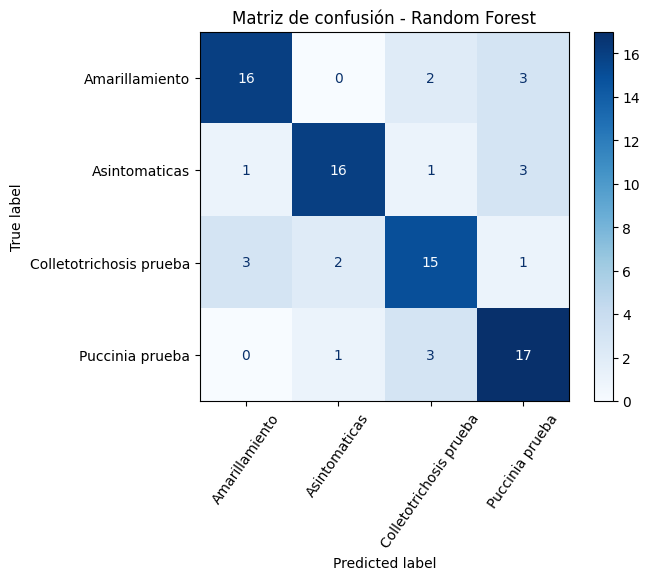

In [38]:
#Nosotros creamos la "matriz de confusión". Es una tabla donde comparamos la realidad (la enfermedad que nosotros sabemos que tiene la hoja)
#contra la predicción (lo que la computadora dijo que era).
cm = confusion_matrix(y_test, y_pred, labels=modelo_rf.classes_)

#Preparamos una herramienta especial para que esa tabla de números se convierta en un gráfico visual, fácil de leer para cualquier persona,
#usando los nombres de las enfermedades como etiquetas.
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=modelo_rf.classes_
)

plt.figure(figsize=(8, 8)) #Nosotros definimos el tamaño del cuadro para que el gráfico sea grande y los nombres de las enfermedades no se amontonen.
disp.plot(cmap="Blues", xticks_rotation=55) #Dibujamos la matriz usando tonos de azul.Nosotros rotamos los nombres de abajo a 45 grados para que se lean claramente sin estorbarse entre sí.
#Le ponemos el título al gráfico y le ordenamos a la computadora que nos lo muestre en pantalla.
plt.title("Matriz de confusión - Random Forest")
plt.show()

Nosotros vemos esta matriz como el "mapa de errores" del proyecto. En este gráfico, los aciertos aparecen en una línea diagonal; si esa línea está muy marcada de azul oscuro, nosotros sabemos que el modelo es muy bueno. Pero lo más interesante para nosotros son los cuadros que quedan fuera de esa línea.

Si, por ejemplo, nosotros vemos que muchas hojas con "Puccinia" fueron clasificadas como "Sanas", el gráfico nos lo mostrará de inmediato. Esto es vital porque nos permite entender si hay dos enfermedades que se parecen tanto entre sí que están confundiendo a la computadora. Como equipo, nosotros no buscamos solo un porcentaje de éxito, sino entender el porqué de cada fallo.

Al final, nosotros usamos este mapa para darle confianza al agricultor. Porque No es lo mismo decir "el sistema acierta el 90%", que decir "el sistema es excelente detectando hongos, pero a veces confunde una quemadura de sol con una bacteria".

Celda 8: importancia de variables

In [53]:
#Nosotros creamos una nueva tabla para organizar la información. En una columna ponemos el nombre de la medida (como "promedio de verde" o "área enferma")
#y en la otra qué tanto valor le dio el modelo a esa medida.
importancias = pd.DataFrame({
    "variable": X.columns, #Aquí el código toma la lista de todas las características que calculamos en la Celda 3
    "importancia": modelo_rf.feature_importances_ #El modelo de Bosque Aleatorio nos entrega un número para cada variable; entre más alto sea el número, más importante fue esa medida para dar el diagnóstico
}).sort_values(by="importancia", ascending=False) #ordenamos la tabla de mayor a menor. Queremos ver primero las variables que fueron más útiles y dejar al final las que casi no aportaron información.
top_variables = importancias["variable"].head(10).tolist()

print("Top variables:")
print(top_variables)


importancias.head(10) #Finalmente, le pedimos al código que nos muestre las 15 variables más importantes de todas las que analizamos.


Top variables:
['area_hoja', 'pcv_lab_b_mean', 'area_sana', 'H_mean', 'LAB_B_mean', 'G_mean', 'L_mean', 'GLCM_energy', 'V_mean', 'NGRDI_mean']


,variable,importancia
0,area_hoja,0.084800
17,pcv_lab_b_mean,0.053213
1,area_sana,0.052029
7,H_mean,0.047654
12,LAB_B_mean,0.043683
5,G_mean,0.042581
10,L_mean,0.037807
29,GLCM_energy,0.035814
9,V_mean,0.034805
15,NGRDI_mean,0.034101


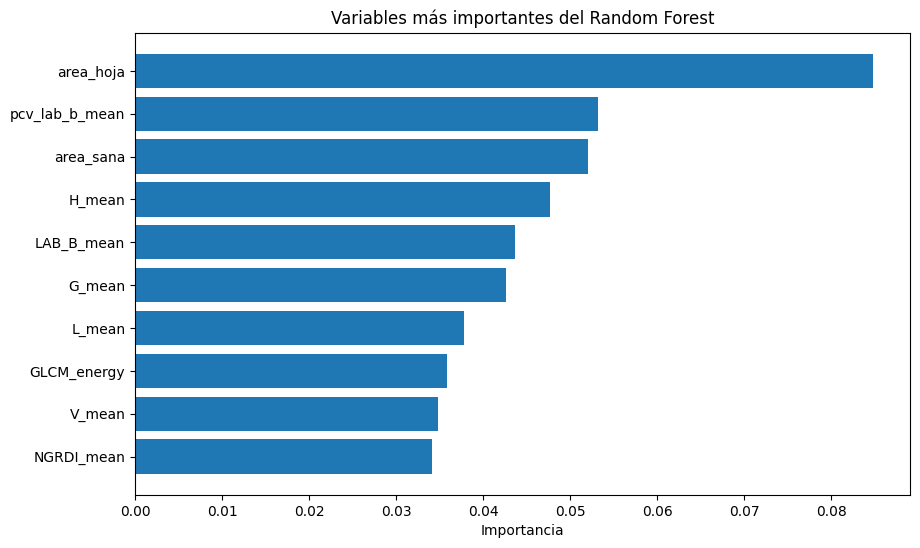

In [51]:
# Gráficamos
plt.figure(figsize=(10, 6))
plt.barh(importancias["variable"].head(10), importancias["importancia"].head(10))
plt.gca().invert_yaxis()
plt.xlabel("Importancia")
plt.title("Variables más importantes del Random Forest")
plt.show()

Celda 9: probar una imagen nueva

In [54]:
def predecir_sintoma(ruta_imagen, modelo, columnas_modelo):
    datos = extraer_caracteristicas_plantcv(
        ruta_imagen,
        visualizar=True
    )

    if datos is None:
        print("La imagen no se pudo segmentar correctamente.")
        return None

    fila = pd.DataFrame([datos])
    fila = fila[columnas_modelo]

    prediccion = modelo.predict(fila)[0]
    probabilidades = modelo.predict_proba(fila)[0]

    print("Clase predicha:", prediccion)

    probas = pd.DataFrame({
        "clase": modelo.classes_,
        "probabilidad": probabilidades
    }).sort_values(by="probabilidad", ascending=False)

    return probas

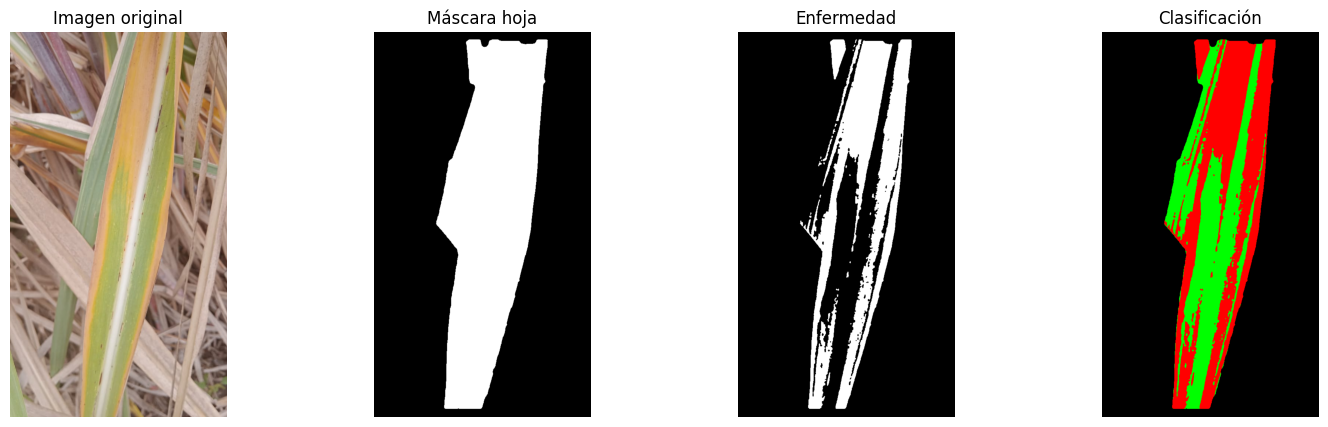

Clase predicha: Amarillamiento


,clase,probabilidad
0,Amarillamiento,0.95
2,Colletotrichosis prueba,0.04
3,Puccinia prueba,0.01
1,Asintomaticas,0.00


In [58]:
ruta_prueba = "/content/drive/MyDrive/Big Data/Trabajo_final/Imágenes/Amarillamiento/scylv_15.jpg"
predecir_sintoma(
    ruta_prueba,
    modelo_rf,
    X.columns
)

10. EVALUAR UNA IMAGEN ALEATORIA DEL DATASET

Codigo ensayo

In [59]:
import random
import os
import numpy as np
import matplotlib.pyplot as plt
from skimage.io import imread

def evaluar_imagen_aleatoria(
    ruta_dataset,
    modelo,
    columnas_modelo
):

    extensiones = (".jpg", ".jpeg", ".png")
    rutas_imagenes = []

    for carpeta_raiz, carpetas, archivos in os.walk(ruta_dataset):
        for archivo in archivos:
            if archivo.lower().endswith(extensiones):
                ruta = os.path.join(carpeta_raiz, archivo)
                rutas_imagenes.append(ruta)

    ruta_aleatoria = random.choice(rutas_imagenes)
    clase_real = os.path.basename(os.path.dirname(ruta_aleatoria))

    print("=" * 60)
    print("Imagen seleccionada:")
    print(ruta_aleatoria)
    print("\nClase real:", clase_real)
    print("=" * 60)

    probabilidades = predecir_sintoma(
        ruta_aleatoria,
        modelo,
        columnas_modelo
    )

    print("\nProbabilidades:")
    display(probabilidades)

    img = imread(ruta_aleatoria)

    resultados_segmentacion = segmentar_hoja_enfermedad_fondo(
        img,
        visualizar=False
    )

    hoja = resultados_segmentacion[0]
    enfermedad = resultados_segmentacion[1]
    fondo = resultados_segmentacion[2]
    hoja_sana = resultados_segmentacion[3]
    clasificada = resultados_segmentacion[4]

    pixeles_hoja = np.sum(hoja)
    pixeles_enfermos = np.sum(enfermedad)
    pixeles_sanos = np.sum(hoja_sana)

    porcentaje_enfermo = (pixeles_enfermos / max(pixeles_hoja, 1)) * 100
    porcentaje_sano = (pixeles_sanos / max(pixeles_hoja, 1)) * 100

    print("\n--- MÉTRICAS ---")
    print("Área hoja:", pixeles_hoja, "píxeles")
    print("Píxeles sanos:", pixeles_sanos)
    print("Píxeles enfermos:", pixeles_enfermos)
    print("Porcentaje sano:", round(porcentaje_sano, 2), "%")
    print("Porcentaje enfermo:", round(porcentaje_enfermo, 2), "%")

    plt.figure(figsize=(15, 4))

    plt.subplot(1, 3, 1)
    plt.imshow(img)
    plt.title("Imagen original")
    plt.axis("off")

    plt.subplot(1, 3, 2)
    plt.imshow(hoja, cmap="gray")
    plt.title("Máscara hoja")
    plt.axis("off")

    plt.subplot(1, 3, 3)
    plt.imshow(clasificada)
    plt.title(f"Afectación: {porcentaje_enfermo:.2f}%")
    plt.axis("off")

    plt.tight_layout()
    plt.show()

    # Histograma de porcentajes
    etiquetas = ["Sano", "Afectado"]
    valores = [porcentaje_sano, porcentaje_enfermo]
    colores = ["green", "red"]

    plt.figure(figsize=(6, 4))
    plt.bar(etiquetas, valores, color=colores)

    for i, v in enumerate(valores):
        plt.text(i, v + 1, f"{v:.2f}%", ha="center")

    plt.ylabel("Porcentaje (%)")
    plt.title("Distribución de hoja sana y afectada")
    plt.ylim(0, 100)
    plt.show()

    return ruta_aleatoria, probabilidades

Imagen seleccionada:
/content/drive/MyDrive/Big Data/Trabajo_final/Imágenes/Amarillamiento/scylv_27.jpg

Clase real: Amarillamiento


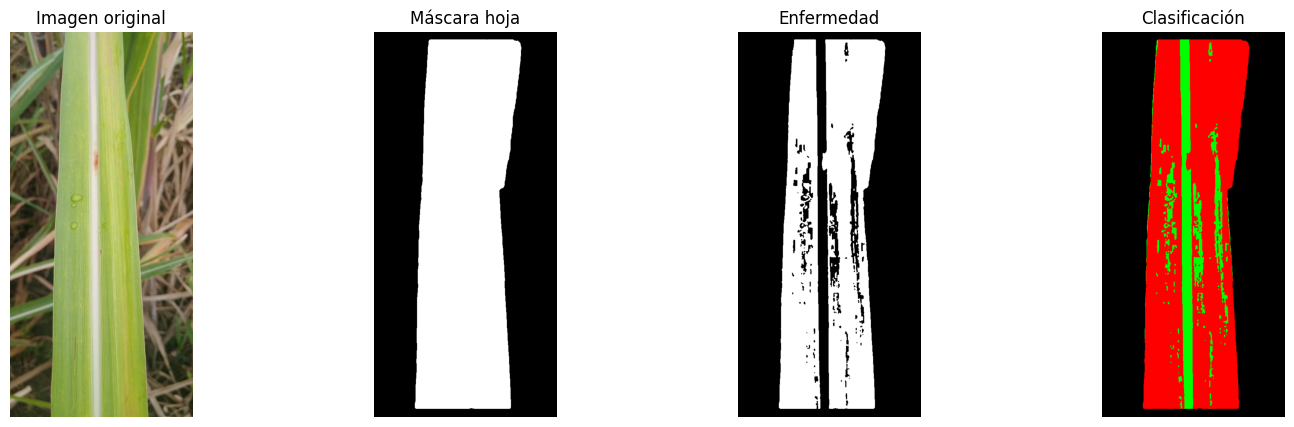

Clase predicha: Amarillamiento

Probabilidades:


,clase,probabilidad
0,Amarillamiento,0.953333
1,Asintomaticas,0.026667
2,Colletotrichosis prueba,0.013333
3,Puccinia prueba,0.006667



--- MÉTRICAS ---
Área hoja: 214056 píxeles
Píxeles sanos: 44013
Píxeles enfermos: 170043
Porcentaje sano: 20.56 %
Porcentaje enfermo: 79.44 %


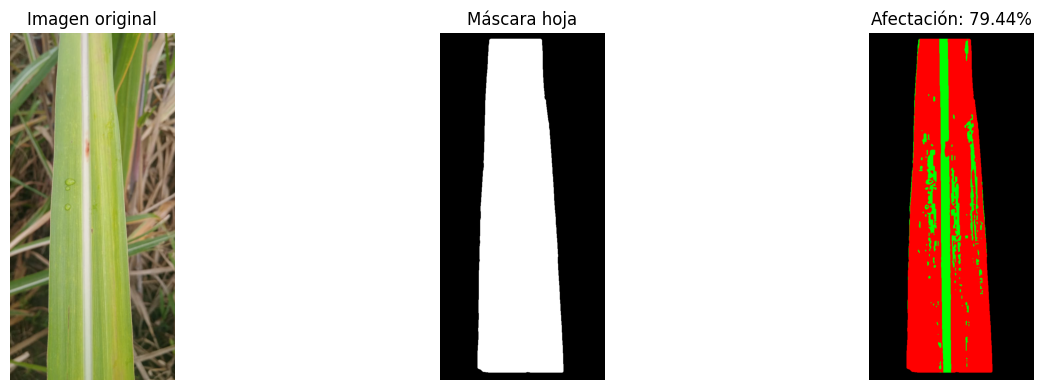

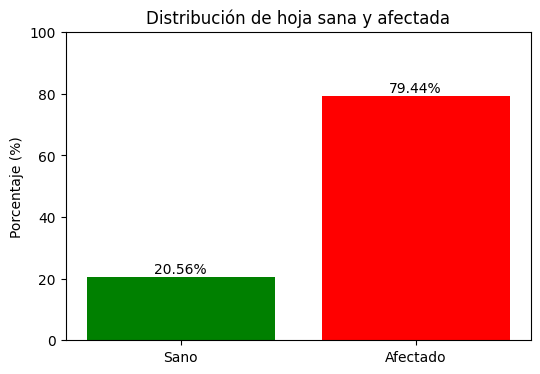

('/content/drive/MyDrive/Big Data/Trabajo_final/Imágenes/Amarillamiento/scylv_27.jpg',
                      clase  probabilidad
 0           Amarillamiento      0.953333
 1            Asintomaticas      0.026667
 2  Colletotrichosis prueba      0.013333
 3          Puccinia prueba      0.006667)

In [66]:
evaluar_imagen_aleatoria(
    ruta_dataset,
    modelo_rf,
    X.columns
)